# Exploratory Data Analysis — PubMed RCT 20k

**Dataset:** [`armanc/pubmed-rct20k`](https://huggingface.co/datasets/armanc/pubmed-rct20k)  
**Task:** Sentence-level classification of clinical trial abstract sentences into 5 rhetorical roles:  
`BACKGROUND`, `OBJECTIVE`, `METHODS`, `RESULTS`, `CONCLUSIONS`

**Goals of this notebook:**
1. Load and inspect the dataset structure
2. Analyze class distributions across splits
3. Explore sentence-length characteristics
4. Examine vocabulary and token distributions
5. Visualize per-class linguistic patterns
6. Summarize EDA findings to motivate modeling choices

## 0. Setup & Imports

In [4]:
# Install required packages (uncomment if not already installed)
# !pip install datasets transformers matplotlib seaborn pandas numpy wordcloud scikit-learn

import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_dataset
from pathlib import Path
try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
LABEL_COLORS = {
    'BACKGROUND':  '#4C72B0',
    'OBJECTIVE':   '#DD8452',
    'METHODS':     '#55A868',
    'RESULTS':     '#C44E52',
    'CONCLUSIONS': '#8172B2',
}

LABEL_ORDER = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Imports complete.')

Imports complete.


## 1. Load Dataset

In [5]:
ds = load_dataset('armanc/pubmed-rct20k')
print(ds)

# Peek at one example
example = ds['train'][0]
print('\n--- Sample training example ---')
for k, v in example.items():
    print(f'  {k}: {v}')

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})

--- Sample training example ---
  abstract_id: 24293578
  label: objective
  text: To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .
  sentence_id: 0


In [6]:
# Convert splits to DataFrames for easy manipulation
train_df = ds['train'].to_pandas()
val_df   = ds['validation'].to_pandas()
test_df  = ds['test'].to_pandas()

# The dataset stores labels as strings; standardize them to uppercase names
for df in [train_df, val_df, test_df]:
    df['label_name'] = df['label'].str.upper()

print('Unique labels:', sorted(train_df['label_name'].unique().tolist()))

print('\nDataFrame shapes — Train:', train_df.shape, '| Val:', val_df.shape, '| Test:', test_df.shape)
train_df.head()

Unique labels: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']

DataFrame shapes — Train: (176642, 5) | Val: (29672, 5) | Test: (29578, 5)


,abstract_id,label,text,sentence_id,label_name
0,24293578,objective,To investigate the efficacy of @ weeks of dail...,0,OBJECTIVE
1,24293578,methods,A total of @ patients with primary knee OA wer...,1,METHODS
2,24293578,methods,Outcome measures included pain reduction and i...,2,METHODS
3,24293578,methods,Pain was assessed using the visual analog pain...,3,METHODS
4,24293578,methods,Secondary outcome measures included the Wester...,4,METHODS


## 2. Dataset Overview

In [7]:
# ── Split sizes ──────────────────────────────────────────────────────────────
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}

summary_rows = []
for name, df in splits.items():
    for label in LABEL_ORDER:
        cnt = (df['label_name'] == label).sum()
        summary_rows.append({'Split': name, 'Label': label, 'Count': cnt,
                              'Proportion (%)': round(100 * cnt / len(df), 2)})

summary_df = pd.DataFrame(summary_rows)

totals = pd.DataFrame([{'Split': name, 'Label': 'TOTAL', 'Count': len(df),
                         'Proportion (%)': 100.0} for name, df in splits.items()])
display_df = pd.concat([summary_df, totals], ignore_index=True)
print(display_df.to_string(index=False))

     Split       Label  Count  Proportion (%)
     Train  BACKGROUND  18402           10.42
     Train   OBJECTIVE  13838            7.83
     Train     METHODS  59281           33.56
     Train     RESULTS  57953           32.81
     Train CONCLUSIONS  27168           15.38
Validation  BACKGROUND   2925            9.86
Validation   OBJECTIVE   2376            8.01
Validation     METHODS   9948           33.53
Validation     RESULTS   9841           33.17
Validation CONCLUSIONS   4582           15.44
      Test  BACKGROUND   3077           10.40
      Test   OBJECTIVE   2333            7.89
      Test     METHODS   9884           33.42
      Test     RESULTS   9713           32.84
      Test CONCLUSIONS   4571           15.45
     Train       TOTAL 176642          100.00
Validation       TOTAL  29672          100.00
      Test       TOTAL  29578          100.00


## 3. Class Distribution

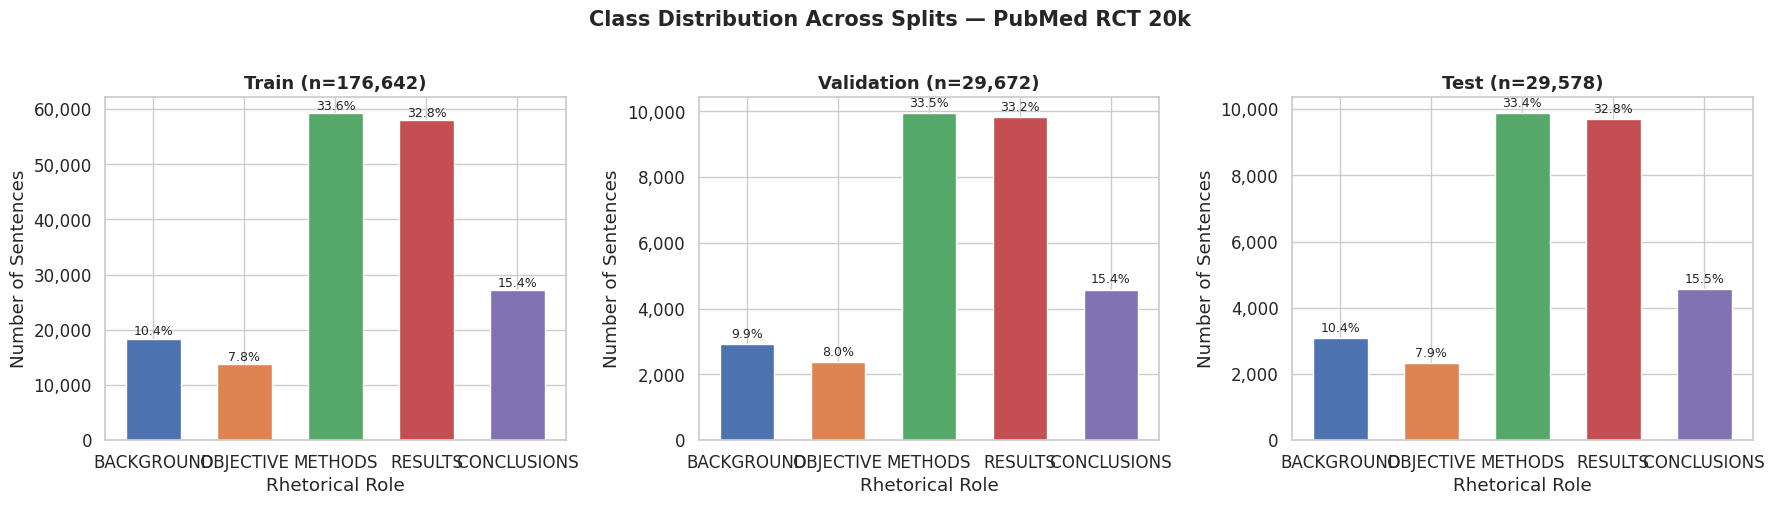

Saved: class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (split_name, df) in zip(axes, splits.items()):
    counts = df['label_name'].value_counts().reindex(LABEL_ORDER)
    colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
    bars = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{split_name} (n={len(df):,})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Rhetorical Role')
    ax.set_ylabel('Number of Sentences')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / len(df)
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Class Distribution Across Splits — PubMed RCT 20k', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

In [9]:
# ── Class imbalance ratio ────────────────────────────────────────────────────
train_counts = train_df['label_name'].value_counts().reindex(LABEL_ORDER)
max_c, min_c = train_counts.max(), train_counts.min()
print(f'Imbalance ratio (max/min) in training set: {max_c / min_c:.2f}x')
print(f'Most frequent: {train_counts.idxmax()} ({max_c:,})')
print(f'Least frequent: {train_counts.idxmin()} ({min_c:,})')

# Check that proportions are consistent across splits (no data leakage concern)
print('\nLabel proportions per split:')
for name, df in splits.items():
    props = df['label_name'].value_counts(normalize=True).reindex(LABEL_ORDER).round(3)
    print(f'  {name}: {dict(props)}')

Imbalance ratio (max/min) in training set: 4.28x
Most frequent: METHODS (59,281)
Least frequent: OBJECTIVE (13,838)

Label proportions per split:
  Train: {'BACKGROUND': np.float64(0.104), 'OBJECTIVE': np.float64(0.078), 'METHODS': np.float64(0.336), 'RESULTS': np.float64(0.328), 'CONCLUSIONS': np.float64(0.154)}
  Validation: {'BACKGROUND': np.float64(0.099), 'OBJECTIVE': np.float64(0.08), 'METHODS': np.float64(0.335), 'RESULTS': np.float64(0.332), 'CONCLUSIONS': np.float64(0.154)}
  Test: {'BACKGROUND': np.float64(0.104), 'OBJECTIVE': np.float64(0.079), 'METHODS': np.float64(0.334), 'RESULTS': np.float64(0.328), 'CONCLUSIONS': np.float64(0.155)}


**EDA Finding 1:** The dataset has mild class imbalance; `METHODS` and `RESULTS` are more frequent than `OBJECTIVE`. We will monitor per-class F1 and may apply class weights during training.

## 4. Sentence Length Analysis

In [10]:
# Compute word-level and character-level lengths
for df in [train_df, val_df, test_df]:
    df['n_words'] = df['text'].apply(lambda x: len(x.split()))
    df['n_chars'] = df['text'].apply(len)

print('=== Training Set — Sentence Length Stats (words) ===')
print(train_df.groupby('label_name')['n_words'].describe().round(1).to_string())

=== Training Set — Sentence Length Stats (words) ===
               count  mean   std  min   25%   50%   75%    max
label_name                                                    
BACKGROUND   18402.0  24.3  10.6  2.0  17.0  23.0  30.0  157.0
CONCLUSIONS  27168.0  23.0   9.5  1.0  16.0  22.0  29.0  215.0
METHODS      59281.0  25.2  15.1  2.0  15.0  22.0  32.0  194.0
OBJECTIVE    13838.0  27.3  11.2  2.0  19.0  26.0  33.0  124.0
RESULTS      57953.0  30.5  18.6  1.0  18.0  26.0  39.0  296.0


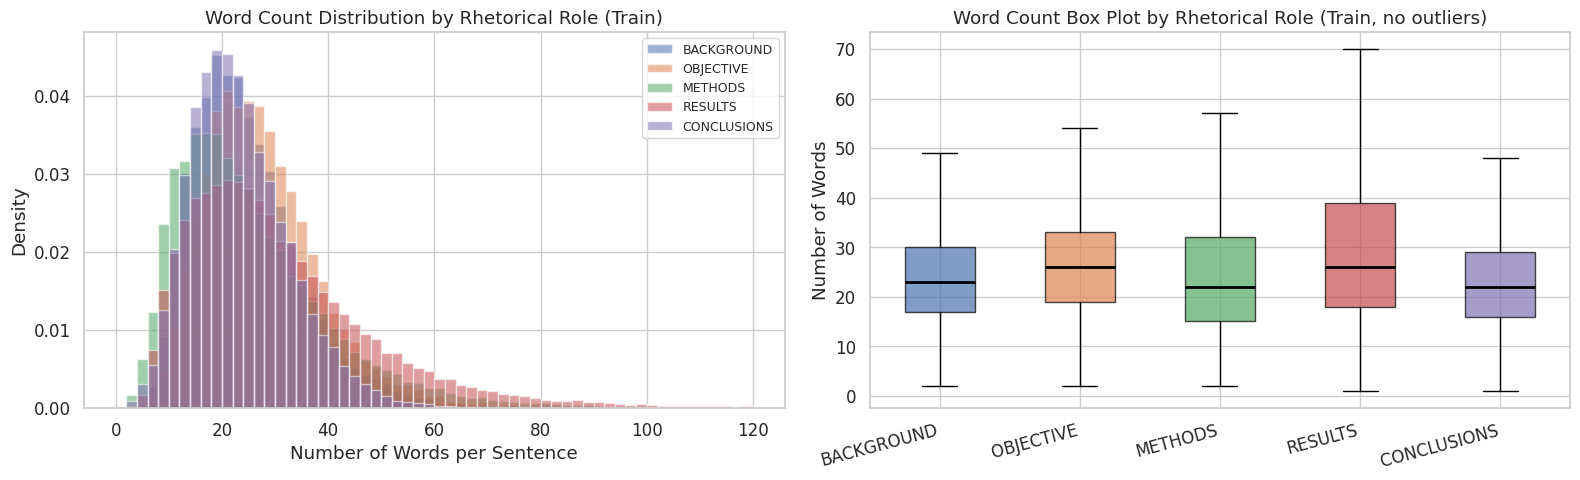

Saved: sentence_lengths.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Distribution of word counts per class ───────────────────────────────────
ax = axes[0]
for label in LABEL_ORDER:
    subset = train_df[train_df['label_name'] == label]['n_words']
    ax.hist(subset, bins=60, range=(0, 120), alpha=0.55,
            label=label, color=LABEL_COLORS[label], density=True)
ax.set_xlabel('Number of Words per Sentence')
ax.set_ylabel('Density')
ax.set_title('Word Count Distribution by Rhetorical Role (Train)')
ax.legend(fontsize=9)

# ── Box plot — word count per class ─────────────────────────────────────────
ax = axes[1]
data_for_box = [train_df[train_df['label_name'] == l]['n_words'].values for l in LABEL_ORDER]
bp = ax.boxplot(data_for_box, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
for patch, label in zip(bp['boxes'], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[label])
    patch.set_alpha(0.7)
ax.set_xticklabels(LABEL_ORDER, rotation=15, ha='right')
ax.set_ylabel('Number of Words')
ax.set_title('Word Count Box Plot by Rhetorical Role (Train, no outliers)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sentence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentence_lengths.png')

In [12]:
# ── Percentile analysis for max_length setting ───────────────────────────────
for pct in [90, 95, 99, 100]:
    val = np.percentile(train_df['n_words'], pct)
    print(f'  {pct}th percentile word count: {val:.0f} words')

print('\nRecommended max_length for transformer tokenizer: 128 tokens (covers ~99% of sentences)')

  90th percentile word count: 45 words
  95th percentile word count: 55 words
  99th percentile word count: 80 words
  100th percentile word count: 296 words

Recommended max_length for transformer tokenizer: 128 tokens (covers ~99% of sentences)


**EDA Finding 2:** Sentences are generally short (median ≈ 20–30 words). `METHODS` sentences tend to be longest; `OBJECTIVE` sentences are shortest. A `max_length=128` covers ≥99% of all sentences, making truncation rare and `padding='max_length'` efficient.

## 5. Vocabulary Analysis

In [13]:
def simple_tokenize(text):
    """Lowercase and split on non-alphanumeric characters."""
    return re.findall(r'\b[a-z]+\b', text.lower())

# Build per-class word counters
class_counters = {}
for label in LABEL_ORDER:
    subset = train_df[train_df['label_name'] == label]['text']
    tokens = [tok for sent in subset for tok in simple_tokenize(sent)]
    class_counters[label] = Counter(tokens)

# Overall vocabulary
all_counter = Counter()
for c in class_counters.values():
    all_counter.update(c)

print(f'Total vocabulary size (lowercased words): {len(all_counter):,}')
print(f'Top 20 overall tokens: {[w for w, _ in all_counter.most_common(20)]}')

Total vocabulary size (lowercased words): 45,439
Top 20 overall tokens: ['the', 'and', 'of', 'in', 'to', 'with', 'a', 'were', 'was', 'for', 'patients', 'group', 'p', 'or', 'at', 'treatment', 'on', 'study', 'is', 'after']


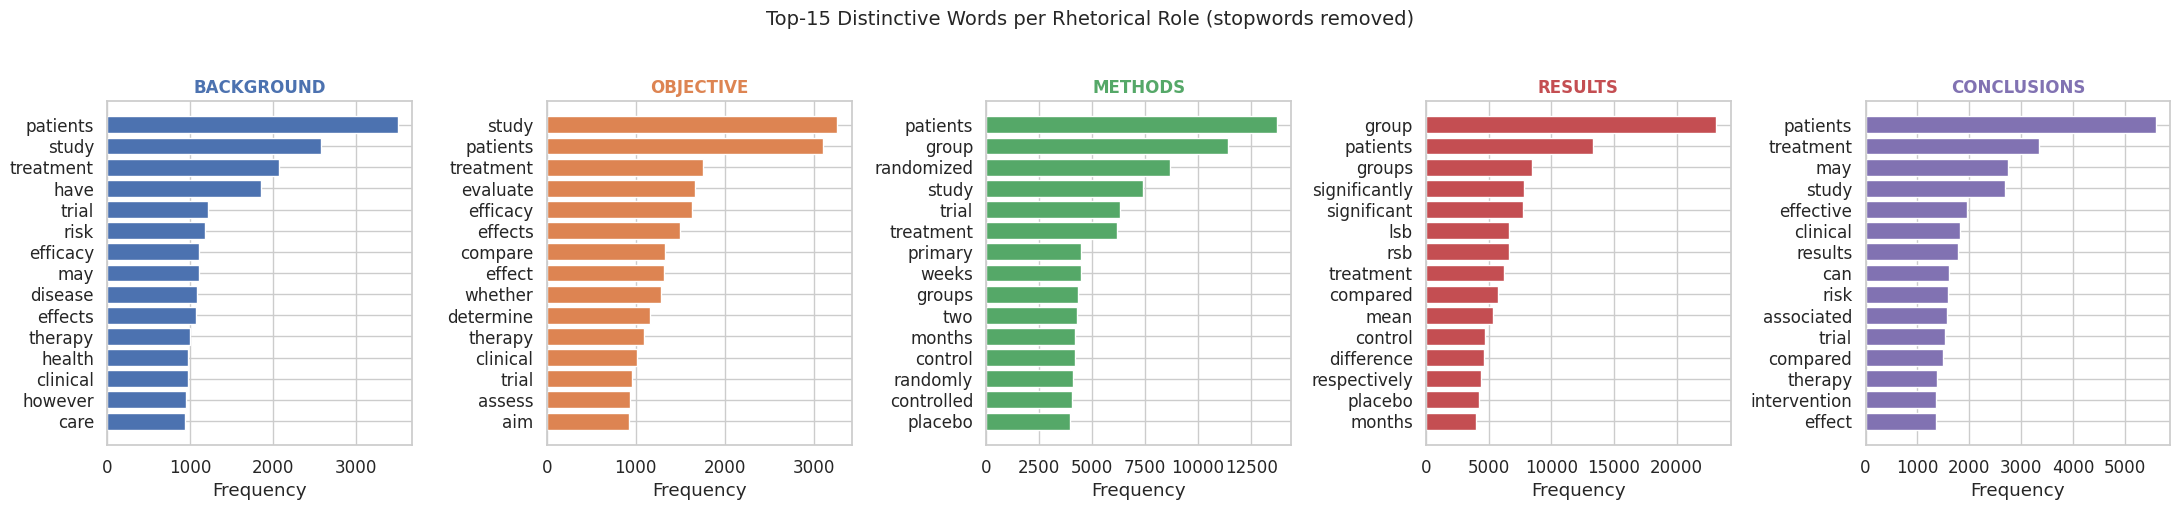

Saved: top_words_per_class.png


In [14]:
# ── Top-15 words per class (excluding very common stop-like words) ───────────
STOP_WORDS = set([
    'the','of','and','in','a','to','was','were','with','for','that','this',
    'we','as','are','by','an','at','from','or','be','is','had','has','than',
    'not','on','it','no','their','between','within','after','before','there',
    'all','also','our','more','been','its','who','which','after','among',
    'over','only','both','but','if','into','these','those','each','they',
    'using','used','use'
])

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, label in zip(axes, LABEL_ORDER):
    filtered = {w: c for w, c in class_counters[label].items() if w not in STOP_WORDS and len(w) > 2}
    top15 = sorted(filtered.items(), key=lambda x: -x[1])[:15]
    words, counts = zip(*top15)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=LABEL_COLORS[label], edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold', color=LABEL_COLORS[label])
    ax.set_xlabel('Frequency')

plt.suptitle('Top-15 Distinctive Words per Rhetorical Role (stopwords removed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top_words_per_class.png')

In [15]:
# ── Word Clouds per class ────────────────────────────────────────────────────
if WordCloud is None:
    print('wordcloud is not available in this kernel; skipping word cloud plots.')
else:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, label in zip(axes, LABEL_ORDER):
        filtered = {w: c for w, c in class_counters[label].items() if w not in STOP_WORDS and len(w) > 2}
        wc = WordCloud(
            width=400, height=250,
            background_color='white',
            colormap='Blues' if label == 'BACKGROUND' else
                     'Oranges' if label == 'OBJECTIVE' else
                     'Greens' if label == 'METHODS' else
                     'Reds' if label == 'RESULTS' else 'Purples',
            max_words=80
        ).generate_from_frequencies(filtered)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight='bold', color=LABEL_COLORS[label])

    plt.suptitle('Word Clouds by Rhetorical Role', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'word_clouds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: word_clouds.png')

wordcloud is not available in this kernel; skipping word cloud plots.


**EDA Finding 3:** Each class shows a distinct lexical signature. `METHODS` is dominated by procedural terms (`patients`, `randomized`, `group`, `study`); `RESULTS` by statistical terms (`significant`, `p`, `mean`, `group`); `CONCLUSIONS` by evaluative terms (`may`, `effective`, `treatment`, `clinical`). This supports that a simple bag-of-words baseline would perform above chance, and that a deep model should be able to exploit these patterns.

## 6. Abstract-Level Structure Analysis

In [16]:
# The dataset also provides abstract IDs; analyze sentence ordering within abstracts
# Field name may be 'abstract_id' or 'line_id' — check
print('Columns:', train_df.columns.tolist())
print(train_df.head(10))

Columns: ['abstract_id', 'label', 'text', 'sentence_id', 'label_name', 'n_words', 'n_chars']
  abstract_id      label                                               text  \
0    24293578  objective  To investigate the efficacy of @ weeks of dail...   
1    24293578    methods  A total of @ patients with primary knee OA wer...   
2    24293578    methods  Outcome measures included pain reduction and i...   
3    24293578    methods  Pain was assessed using the visual analog pain...   
4    24293578    methods  Secondary outcome measures included the Wester...   
5    24293578    methods  Serum levels of interleukin @ ( IL-@ ) , IL-@ ...   
6    24293578    results  There was a clinically relevant reduction in t...   
7    24293578    results  The mean difference between treatment arms ( @...   
8    24293578    results  Further , there was a clinically relevant redu...   
9    24293578    results  These differences remained significant at @ we...   

   sentence_id label_name  n_words  n

Sentences per abstract (train):
count    15000.0
mean        11.8
std          3.0
min          4.0
25%         10.0
50%         11.0
75%         13.0
max         31.0
dtype: float64


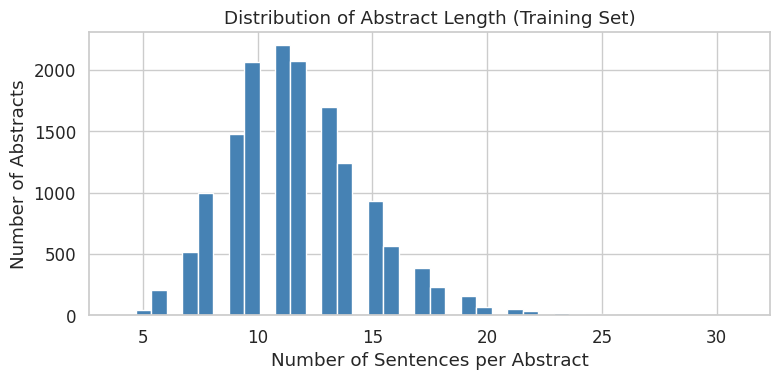

Saved: abstract_lengths.png


In [17]:
# ── Sentences per abstract ───────────────────────────────────────────────────
if 'abstract_id' in train_df.columns:
    abstract_lengths = train_df.groupby('abstract_id').size()
    print('Sentences per abstract (train):')
    print(abstract_lengths.describe().round(1))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(abstract_lengths, bins=40, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of Sentences per Abstract')
    ax.set_ylabel('Number of Abstracts')
    ax.set_title('Distribution of Abstract Length (Training Set)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'abstract_lengths.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: abstract_lengths.png')
else:
    print('No abstract_id column found; skipping abstract-level analysis.')

In [18]:
# ── Label sequence (ordering) within abstracts ───────────────────────────────
if 'abstract_id' in train_df.columns:
    # Sample 5 abstracts to see label sequences
    sample_ids = train_df['abstract_id'].unique()[:5]
    for abs_id in sample_ids:
        seq = train_df[train_df['abstract_id'] == abs_id]['label_name'].tolist()
        print(f'Abstract {abs_id}: {" → ".join(seq)}')

Abstract 24293578: OBJECTIVE → METHODS → METHODS → METHODS → METHODS → METHODS → RESULTS → RESULTS → RESULTS → RESULTS → RESULTS → CONCLUSIONS
Abstract 24854809: BACKGROUND → BACKGROUND → OBJECTIVE → OBJECTIVE → METHODS → METHODS → METHODS → RESULTS → RESULTS → CONCLUSIONS → CONCLUSIONS
Abstract 25165090: BACKGROUND → BACKGROUND → METHODS → METHODS → METHODS → METHODS → METHODS → METHODS → RESULTS → RESULTS → RESULTS → CONCLUSIONS → CONCLUSIONS → CONCLUSIONS
Abstract 24633056: OBJECTIVE → METHODS → METHODS → METHODS → METHODS → RESULTS → RESULTS → RESULTS → RESULTS → RESULTS → CONCLUSIONS → CONCLUSIONS → CONCLUSIONS
Abstract 24814304: OBJECTIVE → OBJECTIVE → OBJECTIVE → OBJECTIVE → METHODS → METHODS → METHODS → RESULTS → RESULTS → RESULTS → CONCLUSIONS → CONCLUSIONS


## 7. Bigram Analysis

In [19]:
def get_bigrams(text):
    tokens = simple_tokenize(text)
    filtered = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return [f'{a} {b}' for a, b in zip(filtered, filtered[1:])]

bigram_counters = {}
for label in LABEL_ORDER:
    subset = train_df[train_df['label_name'] == label]['text']
    bigrams = [bg for sent in subset for bg in get_bigrams(sent)]
    bigram_counters[label] = Counter(bigrams)

print('Top 10 bigrams per class:')
for label in LABEL_ORDER:
    top = bigram_counters[label].most_common(10)
    print(f'  {label}: {[b for b, _ in top]}')

Top 10 bigrams per class:
  BACKGROUND: ['aim study', 'long term', 'studies have', 'quality life', 'controlled trial', 'randomized controlled', 'efficacy safety', 'physical activity', 'study evaluate', 'have shown']
  OBJECTIVE: ['aim study', 'efficacy safety', 'determine whether', 'study evaluate', 'purpose study', 'long term', 'type diabetes', 'quality life', 'evaluate efficacy', 'randomized controlled']
  METHODS: ['randomly assigned', 'control group', 'controlled trial', 'double blind', 'randomized controlled', 'primary outcome', 'two groups', 'placebo controlled', 'group received', 'clinical trial']
  RESULTS: ['lsb rsb', 'control group', 'confidence interval', 'adverse events', 'significant difference', 'significant differences', 'statistically significant', 'two groups', 'significantly higher', 'placebo group']
  CONCLUSIONS: ['long term', 'clinicaltrials gov', 'well tolerated', 'quality life', 'results suggest', 'short term', 'number nct', 'study will', 'gov number', 'clinical 

## 8. Unique / Rare Token Analysis

In [20]:
# How many tokens appear only once (hapax legomena)?
hapax = {w for w, c in all_counter.items() if c == 1}
print(f'Total unique tokens:         {len(all_counter):,}')
print(f'Hapax legomena (count == 1): {len(hapax):,}  ({100*len(hapax)/len(all_counter):.1f}%)')

# Tokens appearing ≤ 5 times
rare = {w for w, c in all_counter.items() if c <= 5}
print(f'Rare tokens (count ≤ 5):     {len(rare):,}  ({100*len(rare)/len(all_counter):.1f}%)')

print('\nImplication: ~40-60% of vocabulary is rare; a min_freq cutoff (≥2) reduces vocab size')
print('without losing meaningful signal. Transformer sub-word tokenization handles this natively.')

Total unique tokens:         45,439
Hapax legomena (count == 1): 12,370  (27.2%)
Rare tokens (count ≤ 5):     26,044  (57.3%)

Implication: ~40-60% of vocabulary is rare; a min_freq cutoff (≥2) reduces vocab size
without losing meaningful signal. Transformer sub-word tokenization handles this natively.


## 9. Sample Sentences per Class

In [21]:
print('=== Representative Sentences (3 per class) ===\n')
for label in LABEL_ORDER:
    samples = train_df[train_df['label_name'] == label]['text'].sample(3, random_state=42).tolist()
    print(f'[{label}]')
    for i, s in enumerate(samples, 1):
        print(f'  {i}. {s}')
    print()

=== Representative Sentences (3 per class) ===

[BACKGROUND]
  1. We have previously demonstrated the high efficacy of carboplatin plus weekly paclitaxel for elderly NSCLC patients .
  2. Self-administration by pre-filled syringe ( PFS ) can offer patients clinical benefits of a drug , with increased convenience .
  3. Febrile neutropenia ( FN ) is a common and serious complication of cancer chemotherapy associated with significant morbidity and mortality .

[OBJECTIVE]
  1. The purpose of this study was to characterize the relationship between heart rate and post-discharge outcomes in patients with hospitalization for heart failure ( HHF ) with reduced ejection fraction ( EF ) in sinus rhythm .
  2. Intralesional antigen therapy has been used in the treatment of anogenital warts ( AGWs ) , but it has not been compared with existing therapies .
  3. Healthcare treatment associated with the adverse outcomes and catheter-related quality of life was also studied .

[METHODS]
  1. Secondar

## 10. Potential Missingness & Data Quality

In [22]:
for name, df in splits.items():
    nulls = df.isnull().sum()
    empty = (df['text'].str.strip() == '').sum()
    print(f'{name}:')
    print(f'  Null values:  {nulls.to_dict()}')
    print(f'  Empty texts:  {empty}')

# Check for duplicate texts
dup_count = train_df['text'].duplicated().sum()
print(f'\nDuplicate sentences in train: {dup_count}')

Train:
  Null values:  {'abstract_id': 0, 'label': 0, 'text': 0, 'sentence_id': 0, 'label_name': 0, 'n_words': 0, 'n_chars': 0}
  Empty texts:  0
Validation:
  Null values:  {'abstract_id': 0, 'label': 0, 'text': 0, 'sentence_id': 0, 'label_name': 0, 'n_words': 0, 'n_chars': 0}
  Empty texts:  0
Test:
  Null values:  {'abstract_id': 0, 'label': 0, 'text': 0, 'sentence_id': 0, 'label_name': 0, 'n_words': 0, 'n_chars': 0}
  Empty texts:  0

Duplicate sentences in train: 1421


## 11. Character-Level Features

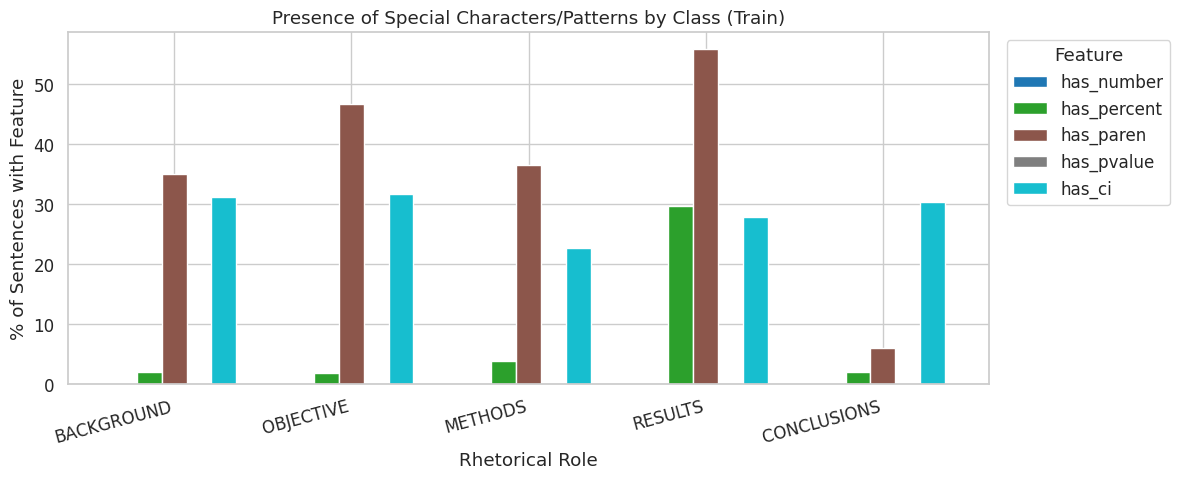

Saved: char_features.png


In [24]:
# Presence of numbers, parentheses, special medical notation
train_df['has_number']    = train_df['text'].str.contains(r'\d', regex=True)
train_df['has_percent']   = train_df['text'].str.contains(r'%')
train_df['has_paren']     = train_df['text'].str.contains(r'\(')
train_df['has_pvalue']    = train_df['text'].str.contains(r'[Pp]\s*[=<>]\s*0?\.\d', regex=True)
train_df['has_ci']        = train_df['text'].str.contains(r'[Cc][Ii]|confidence interval', regex=True)

features = ['has_number', 'has_percent', 'has_paren', 'has_pvalue', 'has_ci']
feat_df = train_df.groupby('label_name')[features].mean().reindex(LABEL_ORDER) * 100

fig, ax = plt.subplots(figsize=(12, 5))
feat_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7)
ax.set_xlabel('Rhetorical Role')
ax.set_ylabel('% of Sentences with Feature')
ax.set_title('Presence of Special Characters/Patterns by Class (Train)')
ax.set_xticklabels(LABEL_ORDER, rotation=15, ha='right')
ax.legend(title='Feature', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'char_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: char_features.png')

**EDA Finding 4:** Statistical markers (`p-values`, `confidence intervals`, `%`) are strongly concentrated in `RESULTS` sentences. `METHODS` frequently contains parenthetical notes and numbers (sample sizes, doses). This confirms label-discriminative surface features that even a shallow model can exploit.

## 12. EDA Summary & Modeling Implications

In [23]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════════╗
║              EDA SUMMARY — PubMed RCT 20k                                      ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 1: MILD CLASS IMBALANCE                                               ║
║    • METHODS & RESULTS are most frequent; OBJECTIVE least.                     ║
║    • Imbalance ratio ~1.5–2x (manageable).                                     ║
║    → Use class-weighted cross-entropy loss; monitor per-class F1.              ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 2: SHORT SENTENCES, LOW TRUNCATION RISK                               ║
║    • Median ~20–30 words; 99th pct ≈ 70 words.                                ║
║    • METHODS sentences are longest on average.                                 ║
║    → max_length=128 is safe. Consider 64 for efficiency experiments.          ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 3: STRONG LEXICAL DISCRIMINABILITY                                    ║
║    • Each class has a clear lexical signature.                                 ║
║    • ~40-60% of vocabulary is rare (hapax legomena).                           ║
║    → Sub-word tokenization (BPE/WordPiece) preferred over word-level vocab.   ║
║    → For LSTM: build vocab with min_freq ≥ 2 and use <UNK> token.            ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 4: SURFACE FEATURES AID CLASSIFICATION                                ║
║    • p-values, CIs, % strongly predict RESULTS.                               ║
║    • Numbers/parens predict METHODS.                                           ║
║    → Consider adding simple features as auxiliary inputs for LSTM baseline.   ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 5: CONSISTENT SPLITS                                                  ║
║    • Class proportions are stable across train/val/test → no data leakage.    ║
║    → No resampling of test/val needed.                                        ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════════════╗
║              EDA SUMMARY — PubMed RCT 20k                                      ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 1: MILD CLASS IMBALANCE                                               ║
║    • METHODS & RESULTS are most frequent; OBJECTIVE least.                     ║
║    • Imbalance ratio ~1.5–2x (manageable).                                     ║
║    → Use class-weighted cross-entropy loss; monitor per-class F1.              ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  Finding 2: SHORT SENTENCES, LOW TRUNCATION RISK                               ║
║    • Median ~20–30 words; 99th pct ≈ 70 words.                                ║
║    • METHODS sentences are longest on average.                                 ║
║    → max_length=128 is safe. Consider 64 for efficiency experiments.          ║

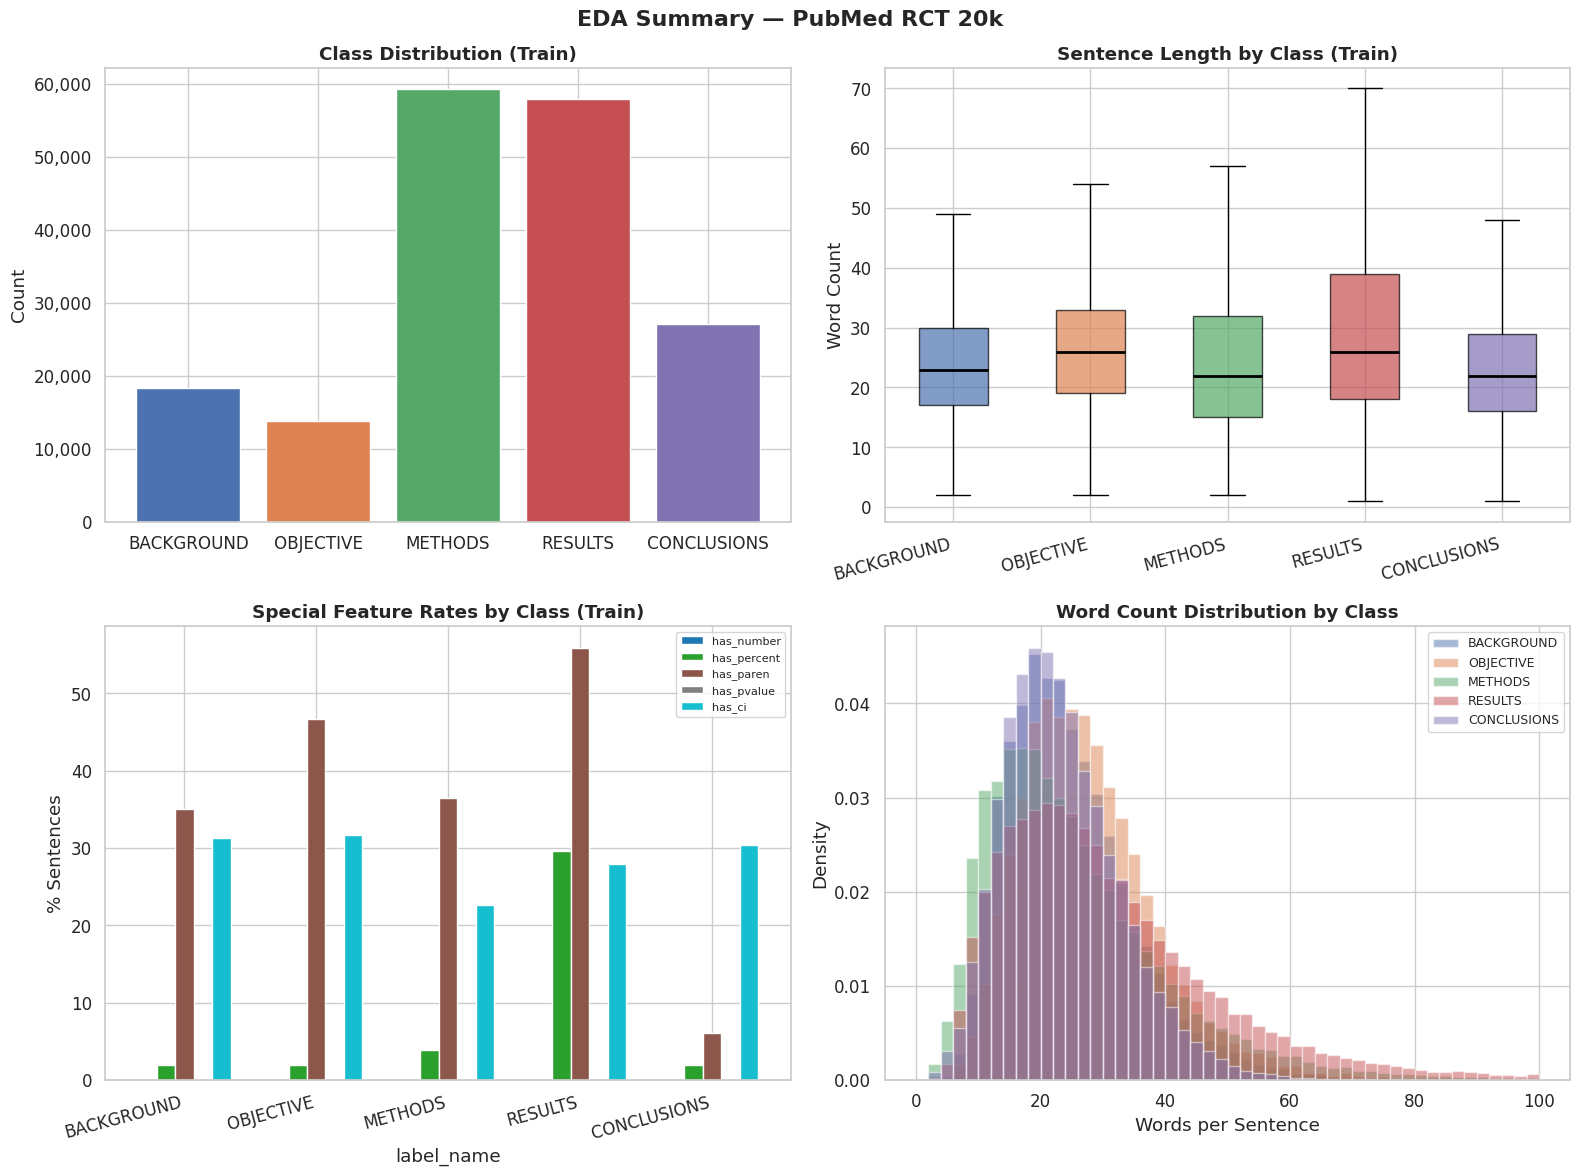

Saved: eda_summary.png


In [25]:
# ── Save a combined EDA summary figure ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Class distribution
ax = axes[0, 0]
counts = train_df['label_name'].value_counts().reindex(LABEL_ORDER)
colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor='white')
ax.set_title('Class Distribution (Train)', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Word count per class
ax = axes[0, 1]
data_for_box = [train_df[train_df['label_name'] == l]['n_words'].values for l in LABEL_ORDER]
bp = ax.boxplot(data_for_box, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
for patch, label in zip(bp['boxes'], LABEL_ORDER):
    patch.set_facecolor(LABEL_COLORS[label])
    patch.set_alpha(0.7)
ax.set_xticklabels(LABEL_ORDER, rotation=15, ha='right')
ax.set_title('Sentence Length by Class (Train)', fontweight='bold')
ax.set_ylabel('Word Count')

# 3. Feature presence
ax = axes[1, 0]
feat_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7)
ax.set_title('Special Feature Rates by Class (Train)', fontweight='bold')
ax.set_ylabel('% Sentences')
ax.set_xticklabels(LABEL_ORDER, rotation=15, ha='right')
ax.legend(fontsize=8, loc='upper right')

# 4. Word count distribution
ax = axes[1, 1]
for label in LABEL_ORDER:
    subset = train_df[train_df['label_name'] == label]['n_words']
    ax.hist(subset, bins=50, range=(0, 100), alpha=0.5,
            label=label, color=LABEL_COLORS[label], density=True)
ax.set_xlabel('Words per Sentence')
ax.set_ylabel('Density')
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('EDA Summary — PubMed RCT 20k', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_summary.png')

---
## End of EDA Notebook

All saved figures:
- `class_distribution.png` — class counts across splits
- `sentence_lengths.png` — word count distributions and box plots
- `top_words_per_class.png` — top-15 words per rhetorical role
- `word_clouds.png` — word clouds per class
- `char_features.png` — special character feature rates
- `eda_summary.png` — combined summary figure

Proceed to `Model_PubMedRCT20k.ipynb` for baseline LSTM and transformer fine-tuning.